# Mushroom Species Recognition
**SDG 3 - Good Health & Well-being | SDG 15 - Life on Land**

This notebook trains an image classifier to identify mushroom species from photos using transfer learning (EfficientNet-B3).

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading & Reduction

The full dataset contains 100+ species. We keep the **30 most frequent classes** with a maximum of 50 training images and 20 validation images per class to speed up training while keeping results meaningful.

In [12]:
BASE_PATH = '/kaggle/input/datasets/zlatan599/mushroom1/'

train_df = pd.read_csv(BASE_PATH + 'train.csv')
val_df   = pd.read_csv(BASE_PATH + 'val.csv')
test_df  = pd.read_csv(BASE_PATH + 'test.csv')

def sample_dataset(df, n_classes=30, samples_per_class=50):
    top_classes = df['label'].value_counts().head(n_classes).index
    df_filtered = df[df['label'].isin(top_classes)]
    return df_filtered.groupby('label').head(samples_per_class).reset_index(drop=True)

train_small = sample_dataset(train_df, n_classes=30, samples_per_class=50)

train_classes = set(train_small['label'].unique())
val_filtered  = val_df[val_df['label'].isin(train_classes)]
val_small     = val_filtered.groupby('label').head(20).reset_index(drop=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_small['label_enc'] = le.fit_transform(train_small['label'])
val_small['label_enc']   = le.transform(val_small['label'])

NUM_CLASSES = len(le.classes_)
print(f"Classes dans train : {NUM_CLASSES}")
print(f"Images train : {len(train_small)} | Images val : {len(val_small)}")

Classes dans train : 30
Images train : 1500 | Images val : 600


## 2. Path Correction

Image paths in the CSV point to `/kaggle/working/` which does not exist at runtime. We remap them to the correct Kaggle input directory.

In [24]:
train_small['image_path'] = train_small['image_path'].str.replace(
    '/kaggle/working/', 
    '/kaggle/input/datasets/zlatan599/mushroom1/', 
    regex=False
)
val_small['image_path'] = val_small['image_path'].str.replace(
    '/kaggle/working/', 
    '/kaggle/input/datasets/zlatan599/mushroom1/', 
    regex=False
)

print(train_small['image_path'][0])
print(os.path.exists(train_small['image_path'][0]))

/kaggle/input/datasets/zlatan599/mushroom1/merged_dataset/Lycoperdon perlatum/34356medium.jpg
True


## 3. Preprocessing & Data Augmentation

Training images are augmented (flip, rotation, color jitter) to improve generalization. Validation images use only resize and normalize. All images are resized to **224×224** and normalized with ImageNet statistics.

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class MushroomDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df['image_path'][idx]
        img      = Image.open(img_path).convert('RGB')
        label    = self.df['label_enc'][idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_loader = DataLoader(MushroomDataset(train_small, train_transform),
                          batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(MushroomDataset(val_small,   val_transform),
                          batch_size=32, shuffle=False, num_workers=2)

## 4. Model - EfficientNet-B3 (Transfer Learning)

We load EfficientNet-B3 pretrained on ImageNet and replace the final layer for our 30-class problem. All backbone weights are frozen at this stage — only the new classification head will be trained first.

In [27]:
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
)

model = model.to(device)

## 5. Training - Phase 1: Head Only (5 epochs)

Only the classification head is trained with `lr=1e-3`. This lets the model quickly adapt to the mushroom classes without disturbing the pretrained features.

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

EPOCHS = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model, train_loader)
    vl, va = eval_epoch(model,  val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tl:.3f} Acc: {ta:.3f} | "
          f"Val Loss: {vl:.3f} Acc: {va:.3f}")

100%|██████████| 47/47 [00:12<00:00,  3.84it/s]


Epoch 1/5 | Train Loss: 3.084 Acc: 0.215 | Val Loss: 2.618 Acc: 0.563


100%|██████████| 47/47 [00:07<00:00,  6.35it/s]


Epoch 2/5 | Train Loss: 2.333 Acc: 0.571 | Val Loss: 2.127 Acc: 0.593


100%|██████████| 47/47 [00:07<00:00,  6.35it/s]


Epoch 3/5 | Train Loss: 1.894 Acc: 0.649 | Val Loss: 1.807 Acc: 0.642


100%|██████████| 47/47 [00:07<00:00,  6.51it/s]


Epoch 4/5 | Train Loss: 1.618 Acc: 0.686 | Val Loss: 1.610 Acc: 0.655


100%|██████████| 47/47 [00:07<00:00,  6.40it/s]


Epoch 5/5 | Train Loss: 1.405 Acc: 0.724 | Val Loss: 1.458 Acc: 0.675


## 6. Training - Phase 2: Fine-Tuning (5 epochs)

The last 3 backbone blocks are unfrozen and trained with a lower `lr=1e-4`. This allows the model to refine deeper visual features specific to mushroom textures and shapes.

In [31]:
for param in model.features[-3:].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=1e-4
)

EPOCHS_FT = 5
for epoch in range(EPOCHS_FT):
    tl, ta = train_epoch(model, train_loader)
    vl, va = eval_epoch(model, val_loader)
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    print(f"FT Epoch {epoch+1}/{EPOCHS_FT} | "
          f"Train Loss: {tl:.3f} Acc: {ta:.3f} | "
          f"Val Loss: {vl:.3f} Acc: {va:.3f}")

100%|██████████| 47/47 [00:08<00:00,  5.69it/s]


FT Epoch 1/5 | Train Loss: 1.046 Acc: 0.765 | Val Loss: 0.948 Acc: 0.753


100%|██████████| 47/47 [00:07<00:00,  5.95it/s]


FT Epoch 2/5 | Train Loss: 0.731 Acc: 0.827 | Val Loss: 0.791 Acc: 0.772


100%|██████████| 47/47 [00:08<00:00,  5.79it/s]


FT Epoch 3/5 | Train Loss: 0.557 Acc: 0.865 | Val Loss: 0.672 Acc: 0.812


100%|██████████| 47/47 [00:07<00:00,  5.90it/s]


FT Epoch 4/5 | Train Loss: 0.425 Acc: 0.894 | Val Loss: 0.606 Acc: 0.837


100%|██████████| 47/47 [00:08<00:00,  5.76it/s]


FT Epoch 5/5 | Train Loss: 0.347 Acc: 0.923 | Val Loss: 0.580 Acc: 0.830


## 7. Learning Curves

Loss and accuracy plotted over all 10 epochs. Both train and val curves decrease together - no overfitting detected.

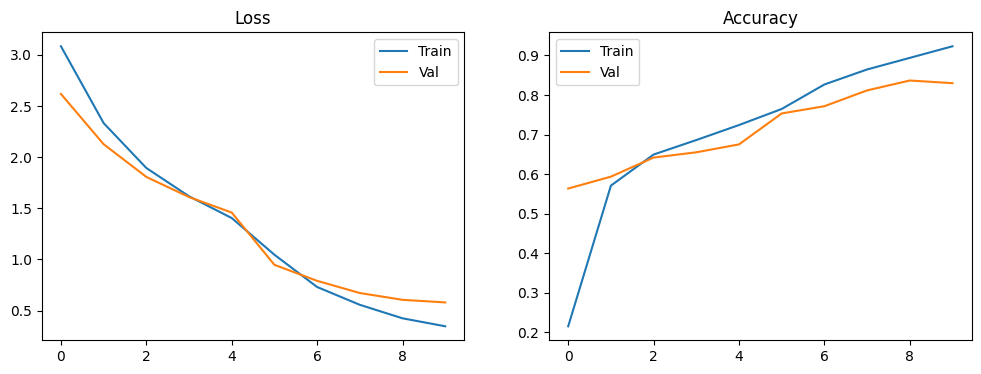

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_accs,  label='Train'); ax2.plot(val_accs,  label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 8. Evaluation - Confusion Matrix & Classification Report

Final evaluation on the validation set (600 images, 30 classes). The confusion matrix shows the top 10 classes. Overall accuracy: **83%**.

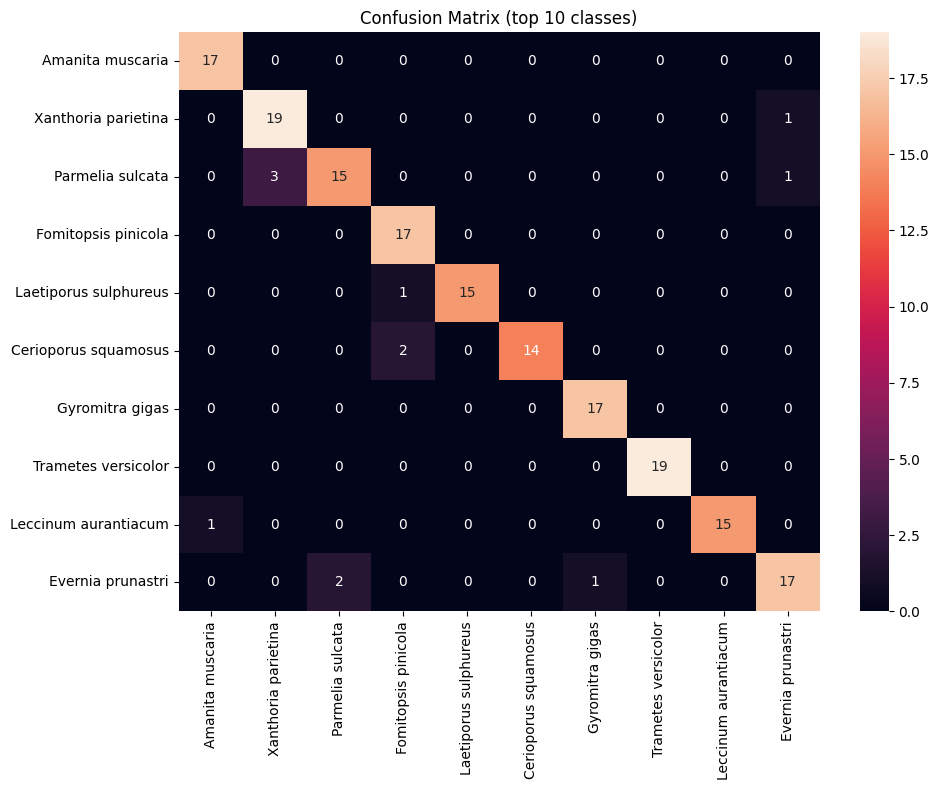

                             precision    recall  f1-score   support

            Amanita citrina       0.82      0.90      0.86        20
           Amanita muscaria       0.81      0.85      0.83        20
         Amanita pantherina       0.75      0.90      0.82        20
             Boletus edulis       0.83      0.50      0.62        20
       Cerioporus squamosus       1.00      0.70      0.82        20
Chlorociboria aeruginascens       0.95      0.90      0.92        20
       Coprinellus micaceus       1.00      0.60      0.75        20
          Evernia prunastri       0.85      0.85      0.85        20
        Fomitopsis pinicola       0.81      0.85      0.83        20
           Grifola frondosa       0.94      0.85      0.89        20
        Gyromitra esculenta       0.86      0.90      0.88        20
            Gyromitra gigas       0.74      0.85      0.79        20
       Hericium coralloides       0.90      0.95      0.93        20
     Laccaria ochropurpurea      

In [33]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

from collections import Counter
top10_idx = [i for i, _ in Counter(all_labels).most_common(10)]
mask = [i for i, l in enumerate(all_labels) if l in top10_idx]
preds_10  = [all_preds[i]  for i in mask]
labels_10 = [all_labels[i] for i in mask]

cm = confusion_matrix(labels_10, preds_10, labels=top10_idx)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_[top10_idx],
            yticklabels=le.classes_[top10_idx])
plt.title('Confusion Matrix (top 10 classes)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=le.classes_))